In [39]:
!pip install kagglehub

In [40]:
import kagglehub

path = kagglehub.dataset_download(
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Dataset Path: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes


In [41]:
import os

print(os.listdir(path))

['data']


In [42]:
for root, dirs, files in os.walk(path):

    print("Root:", root)
    print("Folders:", dirs)
    print("Files:", files[:3])

    print("-"*40)

Root: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes
Folders: ['data']
Files: []
----------------------------------------
Root: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data
Folders: ['labels', 'images', 'labels-YOLO']
Files: ['COCO-conversion-script.py', 'annotations_coco.json', 'README.md']
----------------------------------------
Root: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/labels
Folders: []
Files: ['vlcsnap-2025-02-19-14h18m48s452.txt', 'vlcsnap-2025-02-19-14h21m29s062.txt', 'vlcsnap_2025-03-16-15h14m35s770.txt']
----------------------------------------
Root: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images
Folders: []
Files: ['vlcsnap-2025-02-19-15h10m43s692.jpg', 'vlcsnap-2025-02-18-23h30m34s296.jpg', 'vlcsnap-2025-02-19-14h12m25s165.jpg']
----------------------------------------
Root: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/labels-YOLO
Folders: []
Files: ['vl

In [43]:
IMAGE_PATH = "/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images"

LABEL_PATH = "/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/labels-YOLO"

In [44]:
import os

sample = os.listdir(LABEL_PATH)[0]

with open(os.path.join(LABEL_PATH,sample),"r") as f:
    print(f.read())

2 0.372656 0.575000 0.060938 0.033334
2 0.431250 0.577778 0.043750 0.033333


In [45]:
classes = set()

for file in os.listdir(LABEL_PATH):

    with open(os.path.join(LABEL_PATH,file),"r") as f:

        for line in f:

            cls = int(line.split()[0])

            classes.add(cls)

print(classes)

{0, 1, 2}


In [46]:
import pandas as pd

records = []

for img_file in os.listdir(IMAGE_PATH):

    txt_file = img_file.replace(".jpg",".txt")

    txt_path = os.path.join(
        LABEL_PATH,
        txt_file
    )

    if os.path.exists(txt_path):

        with open(txt_path) as f:

            first_line = f.readline()

            cls = int(first_line.split()[0])

            records.append([
                img_file,
                cls
            ])

df = pd.DataFrame(
    records,
    columns=["image","label"]
)

print(df.head())

                                 image  label
0  vlcsnap-2025-02-19-15h10m43s692.jpg      1
1  vlcsnap-2025-02-18-23h30m34s296.jpg      0
2  vlcsnap-2025-02-19-14h12m25s165.jpg      0
3  vlcsnap-2025-02-19-15h11m08s180.jpg      1
4  vlcsnap-2025-02-18-23h15m30s977.jpg      2


In [47]:
label_map = {
    0:"pothole",
    1:"crack",
    2:"manhole"
}

df["label"] = df["label"].map(label_map)

print(df.head())

                                 image    label
0  vlcsnap-2025-02-19-15h10m43s692.jpg    crack
1  vlcsnap-2025-02-18-23h30m34s296.jpg  pothole
2  vlcsnap-2025-02-19-14h12m25s165.jpg  pothole
3  vlcsnap-2025-02-19-15h11m08s180.jpg    crack
4  vlcsnap-2025-02-18-23h15m30s977.jpg  manhole


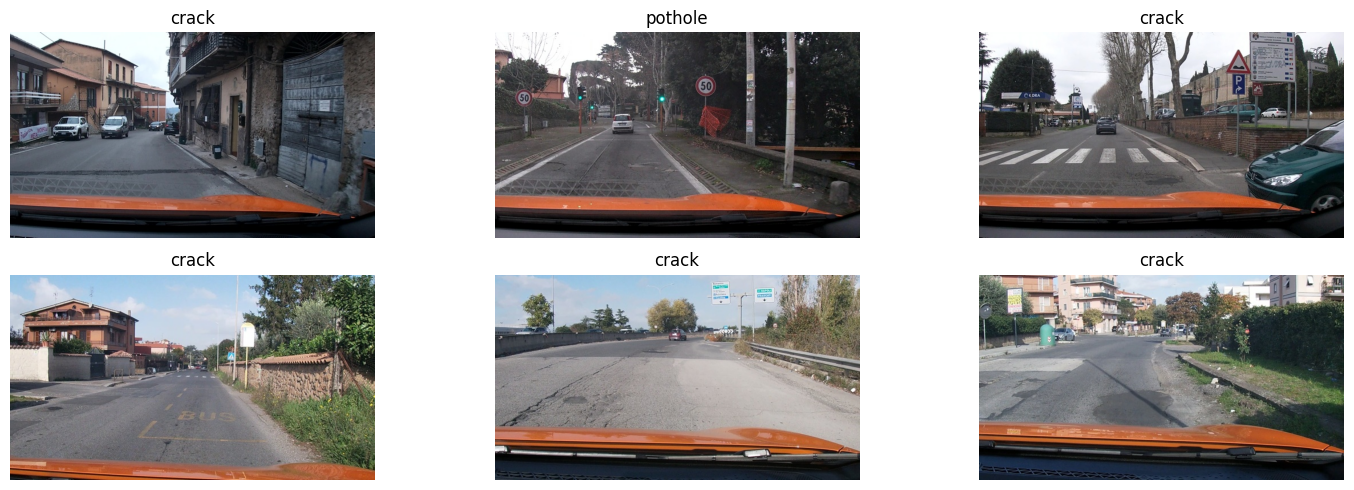

In [48]:
import matplotlib.pyplot as plt
import cv2
import random

plt.figure(figsize=(15,5))

samples = df.sample(6)

for i, (_, row) in enumerate(samples.iterrows()):

    img_path = os.path.join(
        IMAGE_PATH,
        row["image"]
    )

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(
        row["label"]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [49]:
from sklearn.model_selection import train_test_split

train_df,test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

In [51]:
train_data = train_gen.flow_from_dataframe(
    train_df,
    directory=IMAGE_PATH,
    x_col="image",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_gen.flow_from_dataframe(
    test_df,
    directory=IMAGE_PATH,
    x_col="image",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 1607 validated image filenames belonging to 3 classes.
Found 402 validated image filenames belonging to 3 classes.


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        3,
        activation='softmax'
    )

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 744ms/step - accuracy: 0.4798 - loss: 1.3256 - val_accuracy: 0.5000 - val_loss: 1.0342
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 497ms/step - accuracy: 0.4966 - loss: 1.0347 - val_accuracy: 0.5000 - val_loss: 1.0275
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 466ms/step - accuracy: 0.5009 - loss: 1.0269 - val_accuracy: 0.5050 - val_loss: 1.0118
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 486ms/step - accuracy: 0.5040 - loss: 1.0061 - val_accuracy: 0.5149 - val_loss: 1.0275
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 458ms/step - accuracy: 0.4972 - loss: 1.0031 - val_accuracy: 0.4925 - val_loss: 1.0229
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 43s 490ms/step - accuracy: 0.4991 - loss: 0.9762 - val_accuracy: 0.5075 - val_loss: 1.0471
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 476ms/step - accuracy: 0.5252 - loss: 0.9722 - val_accuracy: 0.4925 - val_loss: 1.0283
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 481ms/step - accuracy: 0.5258 - loss: 0.9777 - val_accu

In [55]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

pred = model.predict(
    test_data
)

pred_classes = pred.argmax(
    axis=1
)

true_classes = test_data.classes

print(

classification_report(

    true_classes,

    pred_classes,

    target_names=list(
        test_data.class_indices.keys()
    )

)

)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step
              precision    recall  f1-score   support

       crack       0.51      0.72      0.59       201
     manhole       0.33      0.11      0.17       108
     pothole       0.26      0.23      0.24        93

    accuracy                           0.44       402
   macro avg       0.37      0.35      0.33       402
weighted avg       0.40      0.44      0.40       402



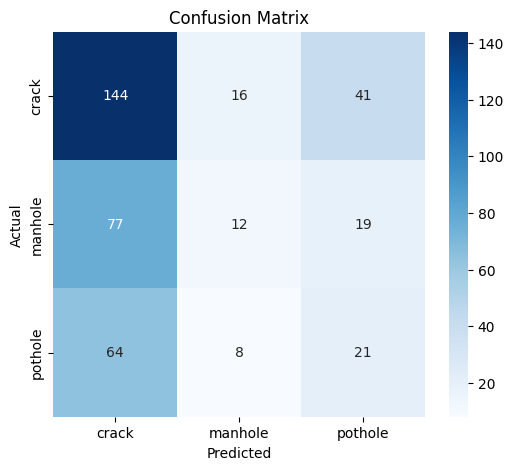

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=list(
        test_data.class_indices.keys()
    ),

    yticklabels=list(
        test_data.class_indices.keys()
    )

)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

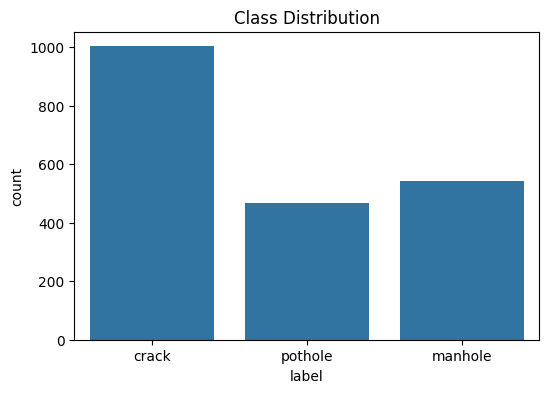

In [57]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["label"]
)

plt.title(
    "Class Distribution"
)

plt.show()

In [58]:
import numpy as np

wrong = np.where(
    pred_classes != true_classes
)[0]

print(
    "Wrong Predictions:",
    len(wrong)
)

Wrong Predictions: 225


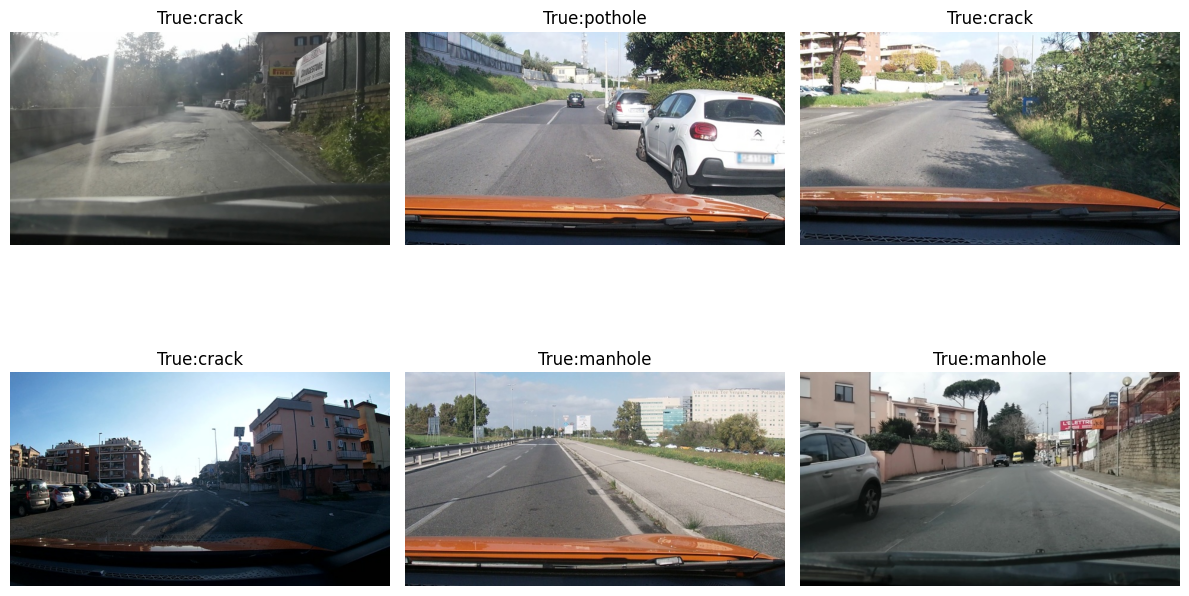

In [59]:
plt.figure(
    figsize=(12,8)
)

for i,idx in enumerate(
    wrong[:6]
):

    img_path = os.path.join(
        IMAGE_PATH,
        test_df.iloc[idx]["image"]
    )

    img = cv2.imread(
        img_path
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(
        2,
        3,
        i+1
    )

    plt.imshow(
        img
    )

    plt.title(

        f"True:{test_df.iloc[idx]['label']}"

    )

    plt.axis(
        "off"
    )

plt.tight_layout()

plt.show()

In [60]:
print("""

Possible Reasons:

1. Similar road patterns

2. Multiple damages in same image

3. Poor lighting

4. Small potholes/cracks

5. Class imbalance

""")



Possible Reasons:

1. Similar road patterns

2. Multiple damages in same image

3. Poor lighting

4. Small potholes/cracks

5. Class imbalance




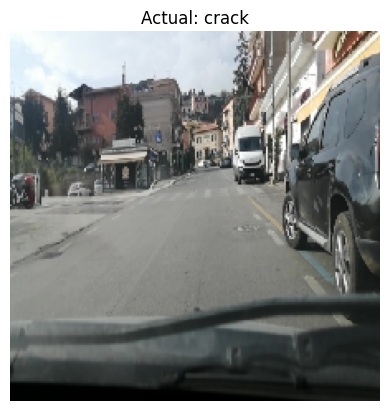

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
Predicted: crack
Actual: crack


In [61]:
import random
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

sample = test_df.sample(1)

img_name = sample.iloc[0]["image"]

actual = sample.iloc[0]["label"]

img_path = os.path.join(
    IMAGE_PATH,
    img_name
)

img = image.load_img(
    img_path,
    target_size=(224,224)
)

plt.imshow(img)

plt.title(
    f"Actual: {actual}"
)

plt.axis("off")

plt.show()

x = image.img_to_array(img)

x = x/255

x = np.expand_dims(
    x,
    axis=0
)

pred = model.predict(x)

labels = dict(

    enumerate(
        train_data.class_indices.keys()
    )

)

prediction = labels[
    np.argmax(pred)
]

print(
    "Predicted:",
    prediction
)

print(
    "Actual:",
    actual
)

In [62]:
# Save trained CNN model

model.save(
    "road_damage_cnn.keras"
)

print(
    "Model saved successfully"
)

Model saved successfully


In [63]:
model.save_weights(
    "road_damage_weights.weights.h5"
)

print(
    "Weights saved successfully"
)

Weights saved successfully


In [64]:
import json

with open(
    "label_mapping.json",
    "w"
) as f:

    json.dump(
        train_data.class_indices,
        f
    )

print(
    "Label mapping saved"
)

Label mapping saved


In [65]:
import os

print(
    os.listdir()
)

['.config', 'road_damage_cnn.keras', 'road_damage_cnn.h5', 'road_damage_weights.weights.h5', 'label_mapping.json', 'sample_data']


In [67]:
from google.colab import files

files.download(
    "road_damage_cnn.keras"
)

files.download(
    "road_damage_weights.weights.h5"
)

files.download(
    "label_mapping.json"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>